In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/k-mean-cluster-dataset/cluster_data.csv


In [2]:
df = pd.read_csv('/kaggle/input/k-mean-cluster-dataset/cluster_data.csv')

In [3]:
print('The shape of Data is:',df.shape)
df.head()

The shape of Data is: (500, 2)


,Feature 1,Feature 2
0,2.698582,-0.672960
1,-0.128113,4.355952
2,2.509049,5.773146
3,-1.518276,3.444886
4,-0.072283,2.883769


In [4]:
df.isnull().sum()

Feature 1    0
Feature 2    0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Feature 1  500 non-null    float64
 1   Feature 2  500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


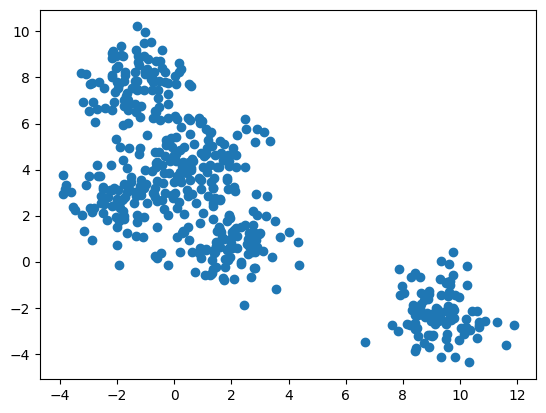

In [6]:
import matplotlib.pyplot as plt
plt.scatter(df['Feature 1'],df['Feature 2'])

In [7]:
from sklearn.cluster import KMeans

In [8]:
wcss = []
for i in range(1,11):
    km = KMeans(n_clusters=i)
    km.fit_predict(df)
    wcss.append(km.inertia_)

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:8

In [9]:
wcss

[14423.995571116939,
 4390.70297788953,
 2183.128805101277,
 1351.6293712365755,
 879.975932176425,
 789.8110995527873,
 714.3024404282729,
 651.4467560898677,
 584.8792215591118,
 521.3800095847898]

Text(0, 0.5, 'WCSS')

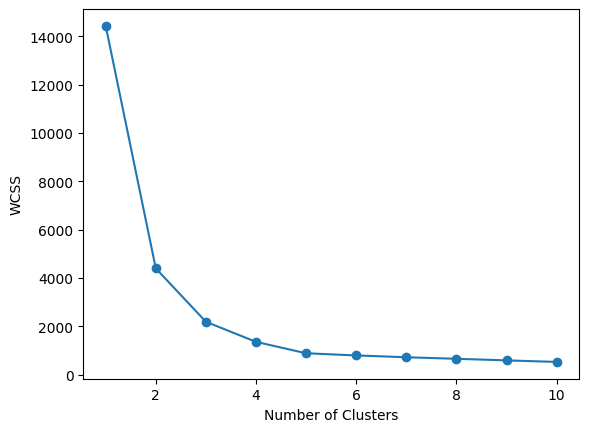

In [10]:
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

In [11]:
X = df.iloc[:,:].values
km = KMeans(n_clusters=4)
y_mean = km.fit_predict(X)

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


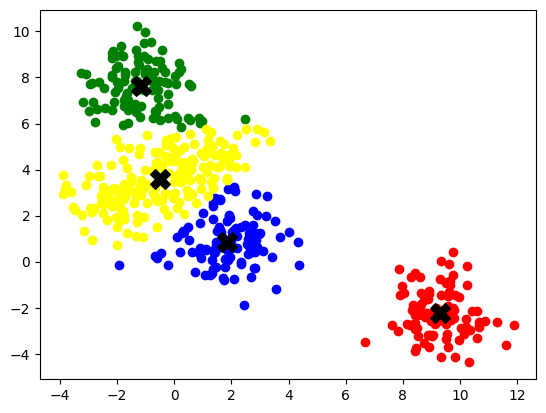

In [12]:
plt.scatter(X[y_mean == 0,0],X[y_mean == 0,1],color='blue')
plt.scatter(X[y_mean == 1,0],X[y_mean == 1,1],color='red')
plt.scatter(X[y_mean == 2,0],X[y_mean == 2,1],color='green')
plt.scatter(X[y_mean == 3,0],X[y_mean == 3,1],color='yellow')
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            s=200, color='black', marker='X', label='Centroids')